# Audio Sales Analysis

## Introduction

As part of this project, I developed a data analytics pipeline for SoundSphere, a fictional European company specializing in the wholesale distribution of audio equipment. The company offers a wide range of products from leading global brands, including professional audio systems, home theaters, portable audio devices, and various accessories.

SoundSphere collaborates with large retail chains and specialized audio equipment stores across Europe. Customers regularly place product orders through the company’s CRM system. These orders are then either confirmed or canceled by managers, depending on specific circumstances.

The company’s team values accurate and secure data storage about their products, clients, and orders. However, during a critical business period, the company faced temporary unavailability of their primary data storage due to planned optimizations. As a result, the data required for analysis was made available only as backup exports, dispersed across multiple directories on the company’s servers.

## Goal

This project demonstrates proficiency in data analytics through the analysis of wholesale sales data in the audio equipment industry. The focus is on consolidating scattered data, performing preprocessing, and deriving actionable insights to support business decisions.

## Objectives

The key objectives of this project are:
1. Consolidate and preprocess data from distributed backups.
2. Analyze sales data to calculate key metrics and identify trends.
3. Provide actionable insights to optimize product offerings, employee performance, and sales strategies.

## Data description

In this project, I used the following tables:

1. **Orders (orders.csv)**:
    - `order_id`: Unique identifier for each order.
    - `product_id`: Identifier for the product in the order.
    - `quantity`: Quantity of the product in the order.

2. **Order status (order_status.csv)**:
    - `order_id`: Identifier matching orders.
    - `client_id`: Unique identifier for the client.
    - `status`: Current status of the order (confirmed or canceled).

3. **Products (products.csv)**:
    - `id`: Unique identifier for the product.
    - `name`: Product name in the format "Brand, Model".
    - `price`: Price of the product in USD.

Each order has a status of either **confirmed** or **canceled**. A single order can include several different products. If an order is canceled and later recreated with the same client, the same products, and the same manager, the database will retain records of both orders with different IDs and statuses. The system does not allow orders with identical IDs to be created.

The data is located in the **data** folder. 

Inside the **data** folder, there are two subfolders: **orders** and **products**.

1. **orders**: Subfolders categorized by date and manager:
    - Example:
        ```
        /data/orders/2024-03-01/Maximilian Berger/orders.csv
        /data/orders/2024-03-01/Maximilian Berger/order_status.csv
        ```

2. **products**: Subfolders categorized by product type:
    - Example:
        ```
        /data/products/AV-processors/products.csv
        ```

Additionally, there is a file named **usd_rate.txt** containing the USD to EUR exchange rate for each day of the analyzed period. The data is provided in the format: `date, rate, currency`. This file will be required during the middle stages of the project.

## Libraries used

The following libraries are used throughout this project for data processing, visualization, and file operations.

In [82]:
# OS library for interacting with the operating system (e.g. file paths, directory listing)
import os

# Pandas for data manipulation and analysis (reading, transforming, and analysing tabular data)
import pandas as pd

# Seaborn for quick and clean statistical data visualisation (based on Matplotlib)
import seaborn as sns

# Plotly Express for interactive visualisation (quickly generate responsive charts)
import plotly.express as px

# Tools from Plotly to create advanced layouts with multiple charts
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Matplotlib for traditional plotting (used for more custom or static visuals)
import matplotlib.pyplot as plt

# NumPy for numerical operations and efficient array handling
import numpy as np

# Datetime for handling time and date conversions and manipulations
import datetime as dt

# Regex library for pattern matching in text (used for cleaning or extracting strings)
import re

---

## Collecting the dataset from folders

### Step 1

**Process description**

I begin by consolidating data from various folders into three dataframes:

1. `df_orders`: I build it based on the `orders.csv` file, adding the `manager` column (with manager names) and the `date` column (with order dates).  
2. `df_order_status`: I create it from the `order_status.csv` file.  
3. `df_products`: I form it based on the `products.csv` file, adding the `category` column (with product categories).  

4. After that, I save the resulting dataframes as the following CSV files:  
- `df_orders.csv`
- `df_order_status.csv`  
- `df_products.csv`

In [83]:
# Define the root path where all order data is stored
orders_way = ('data/orders/')

# Initialize empty DataFrames to store combined results
df_orders = pd.DataFrame()
df_order_status = pd.DataFrame()

# Walk through all subfolders and files inside the orders directory
for path, dirs, files in os.walk(orders_way):
    if files != []:  # Proceed only if there are files in the current directory
        for file in files:
            # Skip hidden files, temporary files, or non-CSV files
            if file.startswith('.') or file.startswith('~$') or not file.lower().endswith('.csv'):
                continue

            # If the file contains "orders" in its name → treat it as an orders file
            if 'orders' in file:
                # Extract folder names for metadata: date (parent folder) and manager (subfolder)
                date = path.split('/')[-2]
                manager = path.split('/')[-1]

                # Read the CSV into a temporary DataFrame
                temp_df = pd.read_csv(f'{path}/{file}')
                
                # Add date and manager info as new columns
                temp_df['date'] = date
                temp_df['manager'] = manager

                # Append this DataFrame to the master orders DataFrame
                df_orders = pd.concat([df_orders, temp_df])

            else:
                # If it's not an "orders" file → treat it as an order status file
                temp_df = pd.read_csv(f'{path}/{file}')

                # Append this DataFrame to the master order_status DataFrame
                df_order_status = pd.concat([df_order_status, temp_df])

In [84]:
# Preview the first 5 rows of the orders dataset to understand its structure
df_orders.head()

,order_id,product_id,quantity,date,manager
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau


In [85]:
# Preview the first 5 rows of the order status dataset to check its format and values
df_order_status.head()

,order_id,client_id,status
0,XRPC-48091227,52,confirmed
0,RJPI-21712323,22,confirmed
0,HCNJ-19162518,54,confirmed
0,DUEU-27693834,14,confirmed
0,JCCF-42586152,49,confirmed


In [86]:
# Define the path to the directory containing product CSV files, organised by category
products_way = ('data/products/')

# Create an empty DataFrame to store all product data
df_products = pd.DataFrame()

# Walk through the directory tree rooted at 'products_way'
for path, dirs, files in os.walk(products_way):
    if files:  # Skip folders with no files
        for file in files:
            if 'products' in file:  # Only process files that include 'products' in the name
                category = path.split('/')[-1]  # Extract category from folder name
                temp_df = pd.read_csv(f'{path}/{file}')  # Load CSV
                temp_df['category'] = category  # Add category as a column
                df_products = pd.concat([df_products, temp_df])  # Append to master DataFrame

# Preview the combined product dataset
df_products.head()

,id,name,price,category
0,62,"Bang & Olufsen, Beosound 1",1602.93,Music center
1,88,"Bose, Wave Music System IV",801.08,Music center
2,89,"Bose, Wave SoundTouch IV",516.14,Music center
3,231,"Denon, DCD-1600NE",738.59,Music center
4,232,"Denon, DCD-600NE",328.51,Music center


In [87]:
# Save cleaned DataFrames to CSV files for future use or inspection

In [88]:
df_orders.to_csv('df_orders.csv', index=False)

In [89]:
df_order_status.to_csv('df_order_status.csv', index=False)

In [90]:
df_products.to_csv('df_products.csv', index=False)

---

## Let’s analyze the overall order trends and identify days that deviate from the general pattern.

### Step 2

**Process description**

I count the number of orders for each day and determine the day with the highest order count.

In [91]:
# Group the orders by date and count how many orders were placed each day
days_by_orders = df_orders.groupby('date', as_index=False) \
                          .agg({'quantity': 'count'}) \
                          .rename(columns={'quantity': 'number_of_orders'}) \
                          .sort_values('number_of_orders', ascending=False)

# Extract the day with the highest number of orders
top_day_by_orders = days_by_orders.head(1)

# Display the result
top_day_by_orders

,date,number_of_orders
13,2024-03-14,437


### Step 3

**Process description**

I create a chart showing the number of orders by weekdays and analyze whether seasonality is evident in the data.

In [92]:
# Preview the top 5 days by number of orders (after grouping and sorting)
days_by_orders.head()

,date,number_of_orders
13,2024-03-14,437
12,2024-03-13,339
0,2024-03-01,302
28,2024-03-29,241
25,2024-03-26,231


In [93]:
# Convert the 'date' column to datetime format for proper time-based operations
days_by_orders.date = pd.to_datetime(days_by_orders.date, format='%Y-%m-%d')

In [94]:
# Extract the weekday name (e.g. 'Monday', 'Tuesday') from each date and store it in a new column
days_by_orders['day_name'] = days_by_orders.date.dt.day_name()

In [95]:
# Group the orders by weekday and sum the number of orders for each day
days_of_the_week_by_orders = days_by_orders.groupby('day_name', as_index=False) \
                                           .agg({'number_of_orders': 'sum'}) \
                                           .sort_values('number_of_orders', ascending=False)

# View the resulting totals per day
days_of_the_week_by_orders

,day_name,number_of_orders
6,Wednesday,985
0,Friday,964
4,Thursday,945
5,Tuesday,828
1,Monday,616
2,Saturday,136
3,Sunday,129


In [96]:
# Create a bar chart showing order volume by day of the week
fig = px.bar(
    days_of_the_week_by_orders,
    x='day_name',
    y='number_of_orders',
    text='number_of_orders',
    title='Weekday vs. Weekend: A Clear Sales Gap',
    labels={'day_name': 'Day of the Week', 'number_of_orders': 'Number of Orders'},
    color='number_of_orders',
    color_continuous_scale='Blues'  # Apply gradient colour for visual contrast
)

# Format the bar labels and hover tooltips
fig.update_traces(
    texttemplate='%{text}',         # Show order count above each bar
    textposition='outside',
    hovertemplate="Day: %{x}<br>Orders: %{y}"  # Custom tooltip format
)

# Apply layout styling: dark theme, dimensions, fonts, and axis settings
fig.update_layout(
    template="plotly_dark",         # Use dark mode for visual consistency
    width=1000,
    height=600,
    uniformtext_minsize=15,
    uniformtext_mode='hide',
    xaxis=dict(
        title='Day of the Week',
        tickfont=dict(size=16),     # Larger tick labels
        titlefont=dict(size=18)     # Larger axis title
    ),
    yaxis=dict(
        title='Number of Orders',
        tickfont=dict(size=16),
        titlefont=dict(size=18)
    ),
    title=dict(font=dict(size=24)),     # Chart title font size
    coloraxis_showscale=False           # Hide colour scale legend
)

# Show the chart
fig.show()

**The chart indicates that there are almost no orders on weekends.**

**Recommendation: Introduce targeted promotions or campaigns on weekends to boost engagement and balance weekly sales.**

### Step 4

**Process description**

It seems that, in addition to the day with the highest number of orders, there is another day that stands out from the overall pattern.

In [97]:
# Preview the dataset before adding new time-based features
days_by_orders.head()

,date,number_of_orders,day_name
13,2024-03-14,437,Thursday
12,2024-03-13,339,Wednesday
0,2024-03-01,302,Friday
28,2024-03-29,241,Friday
25,2024-03-26,231,Tuesday


In [98]:
# Extract the day of the month (1–31) from each date and store it in a new column
days_by_orders['day_of_month'] = days_by_orders['date'].dt.day

# Check the updated DataFrame with the new 'day_of_month' column
days_by_orders.head()

,date,number_of_orders,day_name,day_of_month
13,2024-03-14,437,Thursday,14
12,2024-03-13,339,Wednesday,13
0,2024-03-01,302,Friday,1
28,2024-03-29,241,Friday,29
25,2024-03-26,231,Tuesday,26


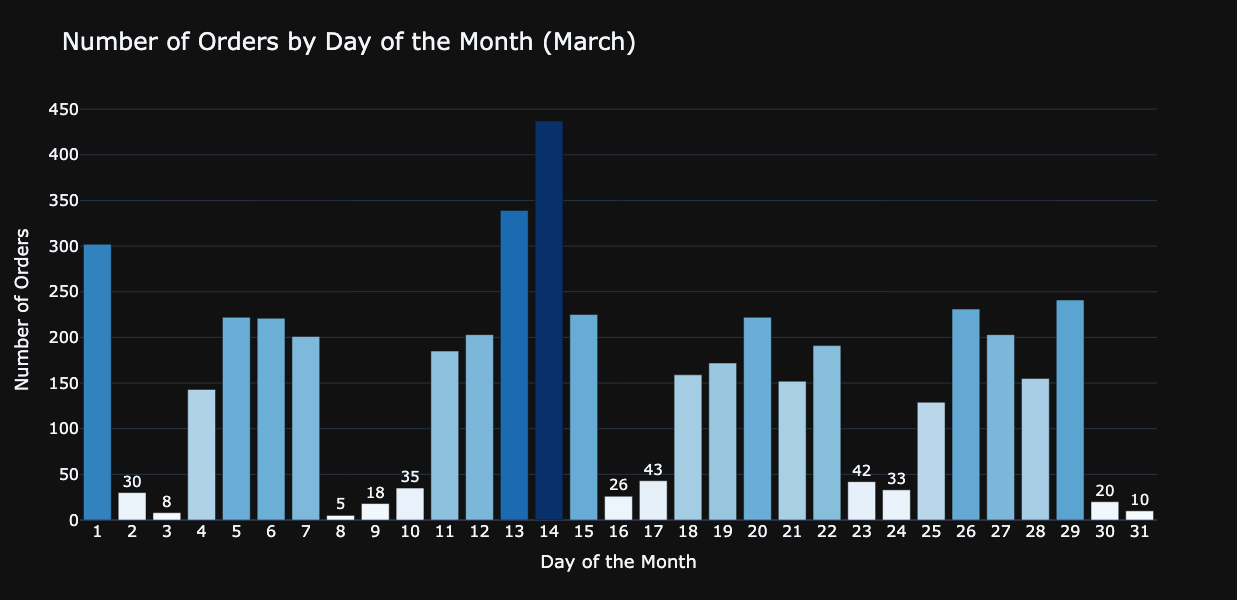

In [99]:
# Create a bar chart showing number of orders by day of the month
fig = px.bar(
    days_by_orders,
    x='day_of_month',
    y='number_of_orders',
    text='number_of_orders',
    title='Number of Orders by Day of the Month (March)',
    labels={'day_of_month': 'Day of the Month', 'number_of_orders': 'Number of Orders'},
    color='number_of_orders',
    color_continuous_scale='Blues'  # Match visual style with previous charts
)

# Display value labels and format hover information
fig.update_traces(
    texttemplate='%{text}',               # Show exact number above each bar
    textposition='outside',
    hovertemplate="Day: %{x}<br>Orders: %{y}"  # Custom hover tooltip
)

# Apply dark theme and improve readability with font sizing and layout tweaks
fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=600,
    uniformtext_minsize=15,
    uniformtext_mode='hide',
    xaxis=dict(
        title='Day of the Month',
        tickfont=dict(size=16),
        titlefont=dict(size=18),
        tickmode='linear',              # Ensure each day is shown sequentially
        tick0=1,
        dtick=1
    ),
    yaxis=dict(
        title='Number of Orders',
        tickfont=dict(size=16),
        titlefont=dict(size=18)
    ),
    title=dict(font=dict(size=24)),
    coloraxis_showscale=False           # Remove the colour gradient legend
)

# Display the chart
fig.show()

**It is a holiday with a low number of orders – 8th March.**

### Step 5

**Process description**

The sales department manager approached me excitedly, asking to identify the reason behind a sudden spike in orders on one particular day. Understanding this will help replicate the success and further increase sales.

Could it be that the marketing team launched a promotional campaign on the day with the highest number of orders (identified in Step 2)? Or perhaps the sales managers actively encouraged companies to place more orders?

To investigate, I start by analyzing the order statuses for that day.

To conduct the analysis, I add order status information to the order data. I combine these into a single dataset and name the resulting DataFrame `orders_status`. I then save the updated DataFrame to a CSV file named `orders_status.csv`.

In [100]:
# Merge order data with order status descriptions to enrich each order with its status name
orders_status = df_orders.merge(df_order_status)

# Preview the merged DataFrame
orders_status.head()

,order_id,product_id,quantity,date,manager,client_id,status
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau,52,confirmed
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau,52,confirmed
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau,52,confirmed
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau,52,confirmed
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau,52,confirmed


In [101]:
# Save the merged orders-status DataFrame to a CSV file for further use or export
orders_status.to_csv('orders_status.csv', index=False)

### Step 6

**Process description**

I examine the quantity and proportion of confirmed and canceled orders. I calculate the share of canceled orders and round the result to two decimal places.

In [102]:
# Count the number of confirmed orders using a query on the merged dataset
confirmed_orders = orders_status.query('status == "confirmed"').shape[0]
confirmed_orders

4083

In [103]:
# Count the number of canceled orders using a similar query
canceled_orders = orders_status.query('status == "canceled"').shape[0]
canceled_orders

520

In [104]:
# Calculate the total number of orders by summing confirmed and canceled
total_number_of_orders = confirmed_orders + canceled_orders
total_number_of_orders

4603

In [105]:
# Calculate the share of canceled orders (as a proportion of total)
share_of_canceled_orders = round(canceled_orders / total_number_of_orders, 2)
share_of_canceled_orders

0.11

### Step 7

**Process description**

I calculate the number of confirmed and canceled orders for each date. I identify the day with no confirmed orders.

To do this, I create a pivot table where rows represent dates, columns represent order statuses, and values represent the number of orders with a given status on a specific date. Missing values are filled with zeros.

In [106]:
# Group orders by date and status, count orders per group
orders_by_date = orders_status.groupby(['date', 'status'], as_index=False) \
                              .agg({'client_id': 'count'}) \
                              .rename(columns={'client_id': 'number_of_orders'}) \
                              .pivot(index='date', columns='status', values='number_of_orders') \
                              .fillna(0) \
                              .reset_index()

# Preview the pivoted dataset with daily counts per status
orders_by_date.head()

status,date,canceled,confirmed
0,2024-03-01,29.0,273.0
1,2024-03-02,0.0,30.0
2,2024-03-03,0.0,8.0
3,2024-03-04,0.0,143.0
4,2024-03-05,0.0,222.0


In [107]:
# Filter days where there were no confirmed orders
day_with_no_confirmed_orders = orders_by_date.loc[orders_by_date['confirmed'] == 0]
day_with_no_confirmed_orders

status,date,canceled,confirmed
8,2024-03-09,18.0,0.0


### Step 8

**Process description**

I create a chart showing the number of orders by day, broken down by order status.

The focus is placed on the day with the highest total number of orders (both confirmed and canceled), identified earlier, as well as the day preceding it for a detailed comparison.

In [108]:
# Calculate total orders by summing confirmed and canceled orders for each day
orders_by_date['total'] = orders_by_date.canceled + orders_by_date.confirmed

# Find the day with the highest total number of orders
top_day_by_orders_df = orders_by_date.sort_values('total', ascending=False).head(1)

# Extract the date of that top-performing day
top_day_by_orders = top_day_by_orders_df.date

top_day_by_orders

13    2024-03-14
Name: date, dtype: object

In [109]:
# Convert the top day's date column to datetime format to allow date arithmetic
top_day_by_orders_df.date = pd.to_datetime(top_day_by_orders_df.date)

# Calculate the previous calendar day based on the top-performing day
previous_day_by_orders = top_day_by_orders_df.date - dt.timedelta(days=1)
previous_day_by_orders

13   2024-03-13
Name: date, dtype: datetime64[ns]

In [110]:
# Ensure the main dataset's date column is also in datetime format for filtering
orders_by_date.date = pd.to_datetime(orders_by_date.date)

# Filter the dataset to find the row corresponding to the previous day
previous_day_by_orders_df = orders_by_date[orders_by_date['date'] == previous_day_by_orders.iloc[0]]

# Combine both the top-performing day and the previous day into one DataFrame for comparison
top_and_previous_days_by_orders_df = pd.concat([top_day_by_orders_df, previous_day_by_orders_df])
top_and_previous_days_by_orders_df

status,date,canceled,confirmed,total
13,2024-03-14,0.0,437.0,437.0
12,2024-03-13,263.0,76.0,339.0


In [111]:
# Reshape the data for plotting: convert 'confirmed' and 'canceled' columns into a single 'status' column
top_2_days_by_orders_long = top_and_previous_days_by_orders_df.melt(
    id_vars='date',
    value_vars=['canceled', 'confirmed'], 
    var_name='status',
    value_name='number_of_orders'
)

# Create a grouped bar chart comparing confirmed and canceled orders on the top two days
fig = px.bar(
    top_2_days_by_orders_long,
    x='date',
    y='number_of_orders',
    text='number_of_orders',
    title='Confirmed vs. Canceled Orders: Top 2 Days',
    labels={'number_of_orders': 'Number of Orders', 'date': 'Date', 'status': 'Order Status'},
    barmode='group',  # group bars side-by-side instead of stacking
    color='status',
    color_discrete_map={'confirmed': '#7fbf7f', 'canceled': '#ff9999'}  # green for confirmed, red for canceled
)

# Add data labels above each bar and define hover info
fig.update_traces(
    texttemplate='%{text}',  # display raw value on the bar
    textposition='outside',
    hovertemplate="Date: %{x}<br>Status: %{legendgroup}<br>Orders: %{y}"  # custom hover tooltip
)

fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=600,
    uniformtext_minsize=15,
    uniformtext_mode='hide',
    xaxis=dict(
        title='Date',
        tickfont=dict(size=16),
        titlefont=dict(size=18),
        tickmode='array',
        tickvals=top_2_days_by_orders_long['date'].unique()  # show only available dates
    ),
    yaxis=dict(
        title='Number of Orders',
        tickfont=dict(size=16),
        titlefont=dict(size=18)
    ),
    title=dict(font=dict(size=24)),
    coloraxis_showscale=False  # hide continuous color legend
)

# Display the interactive plot
fig.show()

The chart shows that:
- on the day with the highest number of orders, there were many successfully completed orders.
- on the day preceding the day with the highest number of orders, there were many cancellations.

### Step 9

**Process description**

I focus on two specific days: the day with the highest number of orders (identified earlier) and the preceding day.

Orders for these two days are analyzed in detail to understand their differences. Based on the analysis, I aim to formulate a hypothesis about the observed patterns or behaviors.

In [112]:
# Filter all orders placed on the top-performing day (2024-03-14)
all_orders_in_top_day = orders_status.loc[orders_status['date'] == '2024-03-14']
all_orders_in_top_day.head()

,order_id,product_id,quantity,date,manager,client_id,status
1116,EZAA-08394172,643,20,2024-03-14,Clara Müller,39,confirmed
1117,EZAA-08394172,1667,40,2024-03-14,Clara Müller,39,confirmed
1118,EZAA-08394172,1497,16,2024-03-14,Clara Müller,39,confirmed
1119,EZAA-08394172,477,10,2024-03-14,Clara Müller,39,confirmed
1120,EZAA-08394172,1657,42,2024-03-14,Clara Müller,39,confirmed


In [113]:
# Filter all orders placed on the day before the top-performing day (2024-03-13)
all_orders_in_previous_day = orders_status.loc[orders_status['date'] == '2024-03-13']
all_orders_in_previous_day.head()

,order_id,product_id,quantity,date,manager,client_id,status
777,AFIH-00611801,511,13,2024-03-13,Andrei Robu,43,canceled
778,AFIH-00611801,240,21,2024-03-13,Andrei Robu,43,canceled
779,AFIH-00611801,583,8,2024-03-13,Andrei Robu,43,canceled
780,AFIH-00611801,468,5,2024-03-13,Andrei Robu,43,canceled
781,AFIH-00611801,648,16,2024-03-13,Andrei Robu,43,canceled


In [114]:
# Merge orders from both days on shared identifiers to find repeating combinations
merged_df = all_orders_in_previous_day.merge(
    all_orders_in_top_day, 
    on=['product_id', 'quantity', 'manager', 'client_id'],  # Join on key business features
    suffixes=('_previous_day', '_top_day')  # Label columns to track source day
)

# Reorder columns for better readability and logical grouping
desired_order_of_columns = [
    'product_id', 'quantity', 'manager', 'client_id',
    'order_id_previous_day', 'date_previous_day', 'status_previous_day', 
    'order_id_top_day', 'date_top_day', 'status_top_day'
]

# Apply the custom column order
ordered_merged_df = merged_df[desired_order_of_columns]
ordered_merged_df

,product_id,quantity,manager,client_id,order_id_previous_day,date_previous_day,status_previous_day,order_id_top_day,date_top_day,status_top_day
0,511,13,Andrei Robu,43,AFIH-00611801,2024-03-13,canceled,FDEB-71487438,2024-03-14,confirmed
1,240,21,Andrei Robu,43,AFIH-00611801,2024-03-13,canceled,FDEB-71487438,2024-03-14,confirmed
2,583,8,Andrei Robu,43,AFIH-00611801,2024-03-13,canceled,FDEB-71487438,2024-03-14,confirmed
3,468,5,Andrei Robu,43,AFIH-00611801,2024-03-13,canceled,FDEB-71487438,2024-03-14,confirmed
4,648,16,Andrei Robu,43,AFIH-00611801,2024-03-13,canceled,FDEB-71487438,2024-03-14,confirmed
...,...,...,...,...,...,...,...,...,...,...
218,57,19,Sophie Dubois,83,RSBH-94158604,2024-03-13,canceled,AUZX-12706022,2024-03-14,confirmed
219,1636,16,Sophie Dubois,83,RSBH-94158604,2024-03-13,canceled,AUZX-12706022,2024-03-14,confirmed
220,1567,18,Sophie Dubois,83,RSBH-94158604,2024-03-13,canceled,AUZX-12706022,2024-03-14,confirmed
221,1566,22,Sophie Dubois,83,RSBH-94158604,2024-03-13,canceled,AUZX-12706022,2024-03-14,confirmed


As observed, the orders repeat those of the previous day. A large number of orders share several parameters: `product_id`, `quantity`, `manager` and `client_id`. However, as expected, the `order_ids` are different.

It is possible that a failure in the CRM system occurred, preventing customers from confirming their orders. As a result, all orders created on the first day were automatically canceled, forcing customers to place them again the next day.

**Almost half of the orders repeat those from the previous day.**

---

## Let’s calculate the key metrics, analyze their dynamics, and create a brief report.

### Step 10

**Process description**

**I have data for an entire month, so it’s time to calculate the key metrics for this period.**

However, there is a challenge: the unit price of goods in the data is listed in US Dollars (USD) because they are purchased in dollars but sold in euros (using the exchange rate for each date). This means the metrics must also be calculated in euros.

Fortunately, I have a text file, `usd_rate.txt`, which contains the USD to EUR exchange rate for each date.

Here’s what I do:
- Open the `usd_rate.txt` file and create a DataFrame with two columns: `date` and `currency_rate`.
- Calculate the average USD to EUR exchange rate for the month.
- Round the result to two decimal places.

In [115]:
# Define the path to the local text file containing USD exchange rate data
path = 'usd_rate.txt'

# Read the content of the file as a list of lines
usd_rate_txt = open(path).readlines()

In [116]:
# Initialize empty lists to store parsed values
date = []
currency_rate = []

# Loop through each line and extract date and exchange rate
for e in usd_rate_txt:
    dates = e.split(',')[0]                     # Extract date from the line
    currency_rates = e.split(',')[1]            # Extract currency rate from the line
    date.append(dates)                          # Append to date list
    currency_rate.append(currency_rates)        # Append to currency_rate list

# Create a DataFrame from the parsed values
usd_rate = pd.DataFrame(
    data={
        'date': date,
        'currency_rate': currency_rate
    }
)

# Display the first few rows of the DataFrame to verify the structure
usd_rate.head()

,date,currency_rate
0,2024-03-01,0.9220
1,2024-03-02,0.9220
2,2024-03-03,0.9220
3,2024-03-04,0.9211
4,2024-03-05,0.9211


In [117]:
# Convert the 'currency_rate' column from string to float
usd_rate = usd_rate.astype({'currency_rate': 'float'})

# Calculate the average exchange rate across the dataset and round to 2 decimals
avg_usd_rate = round(usd_rate.currency_rate.mean(), 2)
avg_usd_rate

0.92

### Step 11

**Process description**

**I begin working with the key metrics by calculating the total revenue.** 

Data on products in confirmed orders is available in the `orders_status` DataFrame, while the unit price of each product can be taken from the `df_products` DataFrame.

Here’s what I do:
- Combine these DataFrames into a unified `df_full` DataFrame.
- Add USD to EUR exchange rate information for each date.
- Create a column to calculate the revenue for each product in the orders.
- Calculate the **total revenue in euros** considering only confirmed orders.
- Round the result to two decimal places.

In [118]:
# Rename the 'id' column in df_products to 'product_id' for consistency with other datasets
df_products.rename(columns={'id': 'product_id'}, inplace=True)

In [119]:
# Merge orders (with status) and product information into a single full dataset
df_full = orders_status.merge(df_products)

In [120]:
# Convert 'date' columns to datetime format for accurate time-based analysis
df_full.date = pd.to_datetime(df_full.date)
usd_rate.date = pd.to_datetime(usd_rate.date)

In [121]:
# Merge the exchange rate data into the full order-product dataset
df_full = df_full.merge(usd_rate)
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,name,price,category,currency_rate
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau,52,confirmed,"Heco, Music Style 200",205.35,Bookshelf speakers,0.9259
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau,52,confirmed,"Sony, BDV-E2100",207.98,Home theater,0.9259
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-IC800BL",217.68,Wall-mounted speakers,0.9259
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, TW-E3A",128.48,Wireless headphones,0.9259
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-SW050BL",106.60,Subwoofer,0.9259


In [122]:
# Calculate revenue per product in EUR using quantity × price × currency_rate
df_full['revenue_of_product_in_eur'] = df_full.quantity * df_full.price * df_full.currency_rate
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,name,price,category,currency_rate,revenue_of_product_in_eur
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau,52,confirmed,"Heco, Music Style 200",205.35,Bookshelf speakers,0.9259,2281.602780
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau,52,confirmed,"Sony, BDV-E2100",207.98,Home theater,0.9259,962.843410
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-IC800BL",217.68,Wall-mounted speakers,0.9259,806.199648
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, TW-E3A",128.48,Wireless headphones,0.9259,2141.273376
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-SW050BL",106.60,Subwoofer,0.9259,1085.710340


In [123]:

# Group only confirmed orders and calculate total revenue per product
total_revenue_by_product = df_full.query('status == "confirmed"') \
    .groupby('product_id', as_index=False) \
    .agg({'revenue_of_product_in_eur': 'sum'}) \
    .rename(columns={'revenue_of_product_in_eur': 'total_revenue_in_eur'})

total_revenue_by_product.head()

,product_id,total_revenue_in_eur
0,2,4424.73174
1,4,4937.10735
2,9,5564.26692
3,10,19595.66336
4,11,10745.15316


In [124]:
# Calculate total confirmed revenue across all products (rounded to 2 decimals)
total_revenue = round(total_revenue_by_product.total_revenue_in_eur.sum(), 2)
total_revenue

20451529.99

### Step 12

**Process description**

**The next metric to calculate is the average receipt for this month (in euros).**

I divide the total revenue by the number of orders. The result is rounded to two decimal places.

In [125]:
# Group confirmed orders by order ID and calculate the total revenue (check) per order
orders_checks = df_full.query('status == "confirmed"') \
                        .groupby('order_id', as_index=False) \
                        .agg({'revenue_of_product_in_eur': 'sum'}) \
                        .rename(columns={'revenue_of_product_in_eur': 'order_check_in_eur'})

orders_checks.head()

,order_id,order_check_in_eur
0,ABID-18767701,63684.972183
1,ACXS-56511429,124809.454330
2,AEDO-27030558,65525.417214
3,AFUU-55889181,51873.441324
4,AFWE-27008187,84340.317651


In [126]:
# Count how many confirmed orders we have
number_of_confirmed_orders = orders_checks.shape[0]
number_of_confirmed_orders

309

In [127]:
# Calculate the average check (total revenue from confirmed orders / number of confirmed orders)
avg_check = round(orders_checks.order_check_in_eur.sum() / number_of_confirmed_orders, 2)
avg_check

66186.18

### Step 13

**Process description**

I calculated the key metrics for the month and now explore their daily dynamics: **revenue**, **average receipt**, and **the number of orders**.

**I analyze the graphs to identify useful hypotheses and correlations.**

In [128]:
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,name,price,category,currency_rate,revenue_of_product_in_eur
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau,52,confirmed,"Heco, Music Style 200",205.35,Bookshelf speakers,0.9259,2281.602780
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau,52,confirmed,"Sony, BDV-E2100",207.98,Home theater,0.9259,962.843410
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-IC800BL",217.68,Wall-mounted speakers,0.9259,806.199648
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, TW-E3A",128.48,Wireless headphones,0.9259,2141.273376
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-SW050BL",106.60,Subwoofer,0.9259,1085.710340


In [129]:
# Filter the dataset to only include confirmed orders
df_confirmed = df_full.query('status == "confirmed"')

In [130]:
# Calculate total revenue per day from confirmed orders
revenue_by_date = df_confirmed.groupby('date', as_index=False) \
                                .agg({'revenue_of_product_in_eur': 'sum'}) \
                                .rename(columns={'revenue_of_product_in_eur': 'revenue'})

revenue_by_date.head()

,date,revenue
0,2024-03-01,1.577345e+06
1,2024-03-02,1.208523e+05
2,2024-03-03,2.572593e+04
3,2024-03-04,6.459440e+05
4,2024-03-05,9.026871e+05


In [131]:
# Calculate individual order receipts (total order value in EUR), grouped by date and order_id
receipts = df_confirmed.groupby(['date', 'order_id'], as_index=False) \
                        .agg({'revenue_of_product_in_eur': 'sum'}) \
                        .rename(columns={'revenue_of_product_in_eur': 'receipt'})

In [132]:
# Compute average receipt size per day by averaging order totals on each date
avg_receipts_by_date = receipts.groupby('date', as_index=False) \
                                .agg({'receipt': 'mean'}) \
                                .rename(columns={'receipt': 'avg_receipt'})

avg_receipts_by_date.head()

,date,avg_receipt
0,2024-03-01,78867.245203
1,2024-03-02,60426.165080
2,2024-03-03,25725.929820
3,2024-03-04,64594.395116
4,2024-03-05,50149.285406


In [133]:
numbers_of_orders_by_date = df_confirmed.groupby('date', as_index=False) \
                                        .agg({'order_id': pd.Series.nunique}) \
                                        .rename(columns={'order_id': 'number_of_orders'})

numbers_of_orders_by_date.head()

,date,number_of_orders
0,2024-03-01,20
1,2024-03-02,2
2,2024-03-03,1
3,2024-03-04,10
4,2024-03-05,18


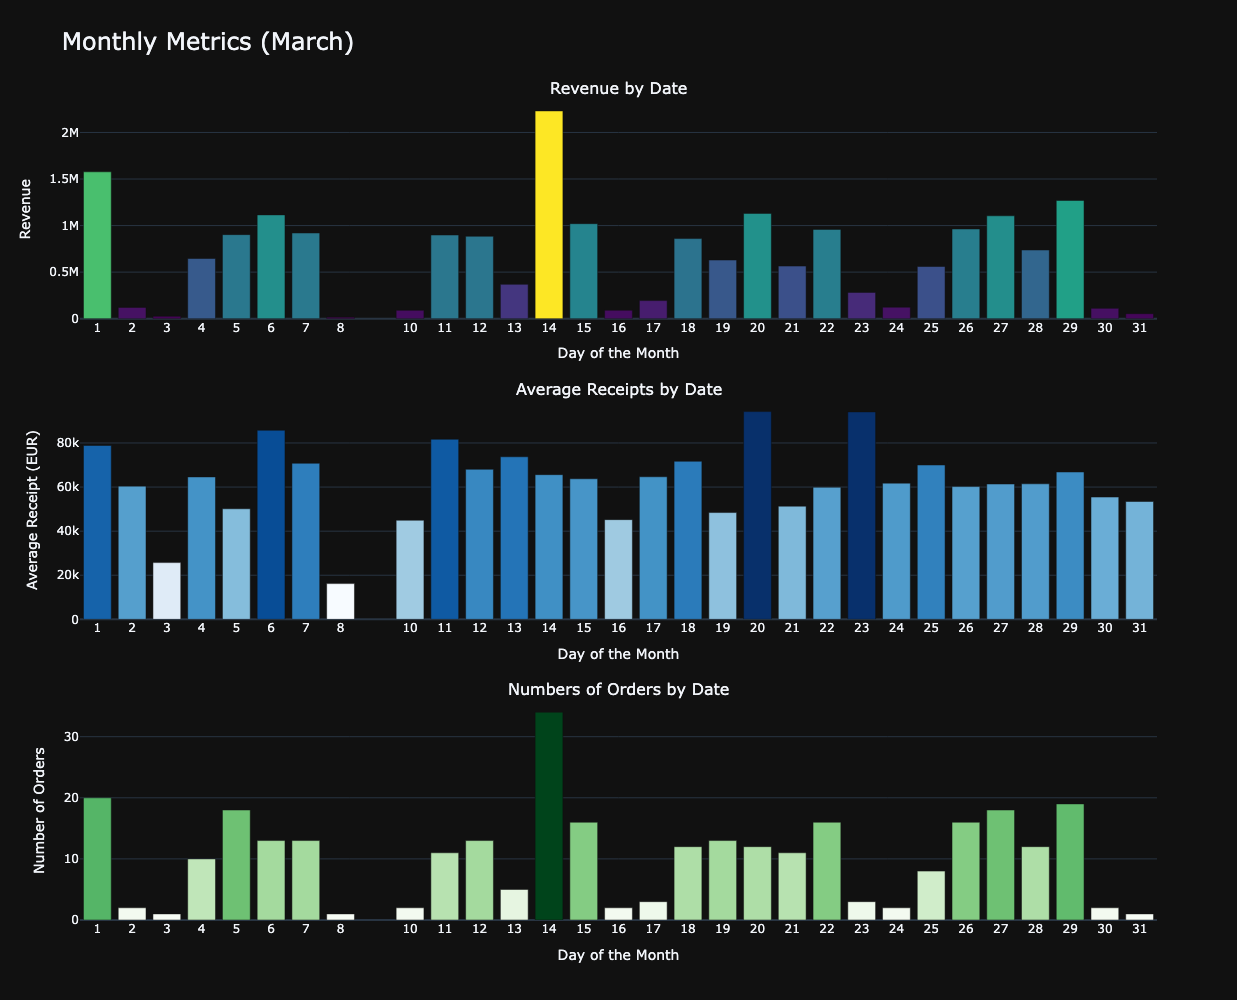

In [134]:
# Add 'day_of_month' column to each dataset for consistent x-axis across all charts
revenue_by_date['day_of_month'] = revenue_by_date['date'].dt.day
avg_receipts_by_date['day_of_month'] = avg_receipts_by_date['date'].dt.day
numbers_of_orders_by_date['day_of_month'] = revenue_by_date['date'].dt.day

# Create a 3-row subplot to visualise monthly trends for:
# 1. Revenue by day
# 2. Average receipt size by day
# 3. Number of orders by day
fig = make_subplots(
    rows=3, cols=1, 
    subplot_titles=[
        "Revenue by Date",
        "Average Receipts by Date",
        "Numbers of Orders by Date"
    ],
    vertical_spacing=0.1
)

# Bar chart for total revenue per day
fig.add_trace(
    go.Bar(
        x=revenue_by_date['day_of_month'],
        y=revenue_by_date['revenue'],
        marker=dict(color=revenue_by_date['revenue'], colorscale='Viridis'),
        name="Revenue"
    ),
    row=1, col=1
)

# Bar chart for average receipt size per day
fig.add_trace(
    go.Bar(
        x=avg_receipts_by_date['day_of_month'],
        y=avg_receipts_by_date['avg_receipt'],
        marker=dict(color=avg_receipts_by_date['avg_receipt'], colorscale='Blues'),
        name="Avg receipt"
    ),
    row=2, col=1
)

# Bar chart for number of confirmed orders per day
fig.add_trace(
    go.Bar(
        x=numbers_of_orders_by_date['day_of_month'],
        y=numbers_of_orders_by_date['number_of_orders'],
        marker=dict(color=numbers_of_orders_by_date['number_of_orders'], colorscale='Greens'),
        name="Number of orders"
    ),
    row=3, col=1
)

fig.update_layout(
    template="plotly_dark",
    height=1000,
    title_text="Monthly Metrics (March)",
    showlegend=False,
    
    xaxis=dict(title="Day of the Month", tickmode='array', tickvals=revenue_by_date['day_of_month']),
    yaxis=dict(title="Revenue"),
    
    xaxis2=dict(title="Day of the Month", tickmode='array', tickvals=avg_receipts_by_date['day_of_month']),
    yaxis2=dict(title="Average Receipt (EUR)"),
    
    xaxis3=dict(title="Day of the Month", tickmode='array', tickvals=numbers_of_orders_by_date['day_of_month']),
    yaxis3=dict(title="Number of Orders"),
    
    title=dict(font=dict(size=24)),
    uniformtext_minsize=15,
    uniformtext_mode='hide'
)

# Render the full dashboard
fig.show()

**The presented graphs indicate the following:**
- The number of orders and revenue do not always change in the same direction daily (e.g., the number of orders might increase, but revenue decreases, and vice versa).
- Average receipt and revenue do not always change in the same direction daily (e.g., the average receipt might increase, but revenue decreases, and vice versa).
- On the day with the highest number of orders, the average receipt do not show maximum value.
- Over time, revenue fluctuates, increasing and decreasing.
- Throughout the month, the average receipt also fluctuates, increasing and decreasing.

---

## Let’s analyze customer interest in brands.

### Step 14

**Process description**

The sales department manager reached out again, this time wanting to understand which brands are popular among customers and which are not.

Using the product names in the `df_full` DataFrame, I create a new column `brand` that contains only the brand names.

To answer the manager’s question, I calculate how many brands customers were interested in. Here, the order status is irrelevant — if a record about a brand appears in the order data, it means the customer either placed or intended to place an order for that brand.

In [135]:
# Extract the brand name from the 'name' column:
# - Splits the string by comma
# - Takes the first element (assumed to be the brand)
# - Removes any leading/trailing whitespace
df_full['brand'] = df_full.name.str.split(',').str[0].str.strip()
df_full.head()

,order_id,product_id,quantity,date,manager,client_id,status,name,price,category,currency_rate,revenue_of_product_in_eur,brand
0,XRPC-48091227,495,12,2024-03-30,Victor Rousseau,52,confirmed,"Heco, Music Style 200",205.35,Bookshelf speakers,0.9259,2281.602780,Heco
1,XRPC-48091227,1445,5,2024-03-30,Victor Rousseau,52,confirmed,"Sony, BDV-E2100",207.98,Home theater,0.9259,962.843410,Sony
2,XRPC-48091227,1635,4,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-IC800BL",217.68,Wall-mounted speakers,0.9259,806.199648,Yamaha
3,XRPC-48091227,1591,18,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, TW-E3A",128.48,Wireless headphones,0.9259,2141.273376,Yamaha
4,XRPC-48091227,1651,11,2024-03-30,Victor Rousseau,52,confirmed,"Yamaha, NS-SW050BL",106.60,Subwoofer,0.9259,1085.710340,Yamaha


In [136]:
# Count the number of unique brands in the dataset
number_of_brands = df_full.brand.nunique()
number_of_brands

121

### Step 15

**Process description**

I calculate the revenue generated by each brand and determine the number of confirmed orders that included products from each brand.

**To identify the most profitable brand, I calculate which brand brought in the highest revenue.**

Additionally, I examine whether this brand appears in more orders compared to others or if it is ordered less frequently but with higher value per order.

In [137]:
# Filter only confirmed orders for further analysis
df_confirmed = df_full.query('status == "confirmed"')

In [138]:
# Calculate total revenue by brand
brands_by_revenue = df_confirmed.groupby('brand', as_index=False) \
                                .agg({'revenue_of_product_in_eur': 'sum'}) \
                                .rename(columns={'revenue_of_product_in_eur': 'revenue'})

# Round revenue values to two decimal places
brands_by_revenue.revenue = round(brands_by_revenue.revenue, 2)
brands_by_revenue.head()

,brand,revenue
0,AKG,45266.92
1,ART,267.44
2,ASUS,2759.65
3,Amazon,20079.03
4,Anker,64793.91


In [139]:
# Identify the brand with the highest total revenue
top_brand_by_revenue = brands_by_revenue.loc[brands_by_revenue['revenue'] == brands_by_revenue.revenue.max()]
top_brand_by_revenue

,brand,revenue
46,JBL,2672543.53


In [140]:
# Count the number of products from each brand per order
number_of_products_by_brand_and_order = df_confirmed.groupby(['order_id', 'brand'], as_index=False) \
                                                    .agg({'revenue_of_product_in_eur': 'count'}) \
                                                    .rename(columns={'revenue_of_product_in_eur': 'number_of_products'}) \
                                                    .sort_values('number_of_products', ascending=False)

number_of_products_by_brand_and_order.head()

,order_id,brand,number_of_products
946,IGWV-35282976,JBL,7
2222,SOCT-63427141,JBL,6
2529,VHJV-14331014,Heco,6
247,CBGL-67898065,JBL,6
2338,TRBS-22489846,JBL,6


In [141]:
# Count how many orders included each brand
number_of_orders_with_brand = number_of_products_by_brand_and_order.groupby('brand', as_index=False) \
                                                                    .agg({'order_id': 'count'}) \
                                                                    .rename(columns={'order_id': 'number_of_orders'}) \
                                                                    .sort_values('number_of_orders', ascending=False)

number_of_orders_with_brand.head()

,brand,number_of_orders
46,JBL,264
43,Heco,229
120,Yamaha,218
53,Klipsch,205
62,Magnat,154


In [142]:
# Calculate revenue per brand within each order
revenue_by_brand_and_order = df_confirmed.groupby(['order_id', 'brand'], as_index=False) \
                                            .agg({'revenue_of_product_in_eur': 'sum'}) \
                                            .rename(columns={'revenue_of_product_in_eur': 'revenue'}) \
                                            .sort_values('revenue', ascending=False)

# Round revenue values to two decimal places
revenue_by_brand_and_order.revenue = round(revenue_by_brand_and_order.revenue, 2)
revenue_by_brand_and_order.head()

,order_id,brand,revenue
2877,ZOUP-11625318,Klipsch,90045.69
67,AIFE-49456074,Sennheiser,88003.84
903,HTDE-97756178,Klipsch,78556.85
1995,RBIQ-57890671,JBL,72984.00
1514,NRZH-55340616,JBL,70849.06


**Based on the obtained data, it can be concluded that JBL was purchased most frequently. Despite the fact that its purchases were made for smaller amounts compared to Klipsch and Sennheiser, JBL remains the leader in terms of the revenue it generated.**

### Step 16

**Process description**

I analyze how well the products from different brands perform in orders. Some brands have most of their products demanded by customers, while others have only a small fraction of their products purchased, leaving the rest to take up virtual “shelf space” in the company’s inventory.

To identify which brands are underperforming, I start by determining which products have been ordered at least once and which have not. For this, I compile a list of unique `product_ids` from the `df_confirmed` DataFrame (containing confirmed orders).

Next, I analyze the `df_products` DataFrame by adding a new column, `is_in_orders`, to indicate whether each product has been ordered (yes) or not (no) during the month.

**Finally I determine the number of products that were ordered and those that were not.**

In [143]:
# Count how many times each product was ordered (only confirmed orders)
numbers_of_orders_by_product = df_confirmed.groupby('product_id', as_index=False) \
                                            .agg({'status': 'count'}) \
                                            .rename(columns={'status': 'number_of_orders'}) \
                                            .sort_values('number_of_orders', ascending=False)

numbers_of_orders_by_product.head()

,product_id,number_of_orders
518,756,17
409,583,15
470,648,13
433,607,13
325,492,13


In [144]:
# Merge product list with order counts to identify which were sold
sold_and_unsold_products = df_products.merge(numbers_of_orders_by_product, how='left')
sold_and_unsold_products

,product_id,name,price,category,number_of_orders
0,62,"Bang & Olufsen, Beosound 1",1602.93,Music center,5.0
1,88,"Bose, Wave Music System IV",801.08,Music center,1.0
2,89,"Bose, Wave SoundTouch IV",516.14,Music center,1.0
3,231,"Denon, DCD-1600NE",738.59,Music center,4.0
4,232,"Denon, DCD-600NE",328.51,Music center,2.0
...,...,...,...,...,...
1672,1456,"Sony, WH-CH510",54.00,Headphones with microphone,3.0
1673,1470,"SteelSeries, Arctis 1",41.59,Headphones with microphone,NaN
1674,1471,"SteelSeries, Arctis 3",57.81,Headphones with microphone,1.0
1675,1472,"SteelSeries, Arctis 5",84.24,Headphones with microphone,4.0


In [145]:
# Rename the column for clarity
sold_and_unsold_products.rename(columns={'number_of_orders': 'is_in_orders'}, inplace=True)

In [146]:
# Mark products as sold ('yes') or unsold ('no')
sold_and_unsold_products.is_in_orders = np.where(sold_and_unsold_products.is_in_orders.notna(), 'yes', 'no')

In [147]:
sold_and_unsold_products

,product_id,name,price,category,is_in_orders
0,62,"Bang & Olufsen, Beosound 1",1602.93,Music center,yes
1,88,"Bose, Wave Music System IV",801.08,Music center,yes
2,89,"Bose, Wave SoundTouch IV",516.14,Music center,yes
3,231,"Denon, DCD-1600NE",738.59,Music center,yes
4,232,"Denon, DCD-600NE",328.51,Music center,yes
...,...,...,...,...,...
1672,1456,"Sony, WH-CH510",54.00,Headphones with microphone,yes
1673,1470,"SteelSeries, Arctis 1",41.59,Headphones with microphone,no
1674,1471,"SteelSeries, Arctis 3",57.81,Headphones with microphone,yes
1675,1472,"SteelSeries, Arctis 5",84.24,Headphones with microphone,yes


In [148]:
# Count how many products were sold vs. not sold
sold_and_unsold_products.is_in_orders.value_counts()

is_in_orders
yes    1180
no      497
Name: count, dtype: int64

### Step 17

**Process description**

About a third of the products were not ordered at all this month. **I analyze this data by brand to determine which brands have more than half of their products unsold.**

However, I exclude brands with a small number of products (less than 15), as they do not significantly contribute to virtual “shelf clutter.”


In [149]:
# Filter out products that were never sold
unsold_products = sold_and_unsold_products.copy()
unsold_products = unsold_products.query('is_in_orders == "no"')

# Extract brand from product name
unsold_products['brand'] = unsold_products.name.str.split(',').str[0]

unsold_products.head()

,product_id,name,price,category,is_in_orders,brand
16,873,"Magnat, MC 200",492.80,Music center,no,Magnat
18,961,"Marantz, M-CR612",595.36,Music center,no,Marantz
19,962,"Marantz, NA6006",664.64,Music center,no,Marantz
26,1074,"Philips, FX80",176.30,Music center,no,Philips
28,1123,"Pioneer, DJ DDJ-400",223.27,Music center,no,Pioneer


In [150]:
# Extract brand from product name
sold_and_unsold_products['brand'] = sold_and_unsold_products.name.str.split(',').str[0]

sold_and_unsold_products.head()

,product_id,name,price,category,is_in_orders,brand
0,62,"Bang & Olufsen, Beosound 1",1602.93,Music center,yes,Bang & Olufsen
1,88,"Bose, Wave Music System IV",801.08,Music center,yes,Bose
2,89,"Bose, Wave SoundTouch IV",516.14,Music center,yes,Bose
3,231,"Denon, DCD-1600NE",738.59,Music center,yes,Denon
4,232,"Denon, DCD-600NE",328.51,Music center,yes,Denon


In [151]:
# Calculate brands with more than 15 products in total
brands_with_more_than_15_products = sold_and_unsold_products.groupby('brand', as_index=False) \
                                                            .agg({'is_in_orders': 'count'}) \
                                                            .rename(columns={'is_in_orders': 'number_of_products'}) \
                                                            .sort_values('number_of_products', ascending=False) \
                                                            .query('number_of_products > 15')

brands_with_more_than_15_products

,brand,number_of_products
57,JBL,115
144,Yamaha,106
94,Pioneer,103
76,Magnat,92
54,Heco,91
60,KEF,82
53,Harman Kardon,80
111,Sennheiser,76
101,Q-Acoustics,75
39,Edifier,73


In [152]:
# Count how many of those products were never sold
numbers_of_unsold_products_by_brand = unsold_products.groupby('brand', as_index=False) \
                                                        .agg({'is_in_orders': 'count'}) \
                                                        .rename(columns={'is_in_orders': 'number_of_unsold_products'}) \
                                                        .sort_values('number_of_unsold_products', ascending=False)

numbers_of_unsold_products_by_brand

,brand,number_of_unsold_products
64,Pioneer,70
39,KEF,54
18,Dali,49
51,Magnat,21
24,Edifier,20
...,...,...
49,MXL,1
50,Mackie,1
55,Music Hall,1
56,Musical Fidelity,1


In [153]:
df_merged = brands_with_more_than_15_products.merge(numbers_of_unsold_products_by_brand)
df_merged

,brand,number_of_products,number_of_unsold_products
0,JBL,115,7
1,Yamaha,106,15
2,Pioneer,103,70
3,Magnat,92,21
4,Heco,91,6
5,KEF,82,54
6,Harman Kardon,80,19
7,Sennheiser,76,20
8,Q-Acoustics,75,13
9,Edifier,73,20


In [154]:
# Merge and calculate percentage of unsold products
df_merged['percentage_of_unsold_products'] = round(df_merged.number_of_unsold_products / df_merged.number_of_products * 100)
df_merged

,brand,number_of_products,number_of_unsold_products,percentage_of_unsold_products
0,JBL,115,7,6.0
1,Yamaha,106,15,14.0
2,Pioneer,103,70,68.0
3,Magnat,92,21,23.0
4,Heco,91,6,7.0
5,KEF,82,54,66.0
6,Harman Kardon,80,19,24.0
7,Sennheiser,76,20,26.0
8,Q-Acoustics,75,13,17.0
9,Edifier,73,20,27.0


In [155]:
# Filter brands where more than 50% of products were unsold
brands_with_most_unsold_products = df_merged.query('percentage_of_unsold_products > 50')
brands_with_most_unsold_products

,brand,number_of_products,number_of_unsold_products,percentage_of_unsold_products
2,Pioneer,103,70,68.0
5,KEF,82,54,66.0
11,Dali,67,49,73.0
17,Marantz,22,19,86.0


**The following brands have more than half of their products unsold this month:**

- Pioneer
- KEF
- Dali
- Marantz

---

## Let’s prepare a report on sales by managers.

### Step 18

**Process description**

To help the company evaluate the performance of its sales team, **I prepare a report on each manager’s deals.** The report includes the number of confirmed orders they processed and the revenue those orders generated.

To provide better clarity, **I calculate each manager’s contribution as a percentage of the total monthly revenue and total number of orders.** This will help the company decide whom to reward and whom to coach based on their monthly performance.

**I will calculate the metrics and visualize the results for easier decision-making.**

In [156]:
# Calculate total revenue from all confirmed orders
total_revenue = round(df_confirmed.revenue_of_product_in_eur.sum(), 2)
total_revenue

20451529.99

In [157]:
# Calculate total revenue generated by each manager
total_revenue_by_manager = df_confirmed.groupby('manager', as_index=False) \
                                        .agg({'revenue_of_product_in_eur': 'sum'}) \
                                        .rename(columns={'revenue_of_product_in_eur': 'total_revenue'})

In [158]:
# Calculate revenue share (%) per manager
total_revenue_by_manager['percentage'] = round(total_revenue_by_manager.total_revenue / total_revenue * 100, 2)
total_revenue_by_manager = total_revenue_by_manager.sort_values('percentage', ascending=False) \
                                                    .reset_index(drop=True)

total_revenue_by_manager

,manager,total_revenue,percentage
0,Margareta Jansen,3.487236e+06,17.05
1,Victor Rousseau,3.200250e+06,15.65
2,Maximilian Berger,2.406282e+06,11.77
3,Jakob Wegner,2.096208e+06,10.25
4,Andrei Robu,1.961403e+06,9.59
5,Salma Novak,1.823627e+06,8.92
6,Sophie Dubois,1.782880e+06,8.72
7,Isabelle Lefevre,1.352156e+06,6.61
8,Clara Müller,1.239638e+06,6.06
9,Anton Gruber,5.169165e+05,2.53


In [159]:
# Count total number of confirmed orders
total_number_of_orders = df_confirmed.groupby('order_id', as_index=False) \
                                        .agg({'status': 'count'}).shape[0]

total_number_of_orders

309

In [160]:
# Assign each order to its responsible manager
# Assumes one manager per order

all_orders_by_manager = df_confirmed.groupby('order_id', as_index=False) \
                                    .agg({'manager': pd.Series.unique})

all_orders_by_manager['manager'] = all_orders_by_manager['manager'].str[0]

total_numbers_of_orders_by_manager = all_orders_by_manager.groupby('manager', as_index=False) \
                                                            .agg({'order_id': 'count'}) \
                                                            .rename(columns={'order_id': 'total_number_of_orders'}) \
                                                            .sort_values('total_number_of_orders', ascending=False) \
                                                            .reset_index(drop=True)

total_numbers_of_orders_by_manager['percentage'] = round(total_numbers_of_orders_by_manager.total_number_of_orders / total_number_of_orders * 100, 2)
total_numbers_of_orders_by_manager = total_numbers_of_orders_by_manager.sort_values('percentage', ascending=False)
total_numbers_of_orders_by_manager

,manager,total_number_of_orders,percentage
0,Victor Rousseau,50,16.18
1,Margareta Jansen,48,15.53
2,Maximilian Berger,40,12.94
3,Jakob Wegner,31,10.03
4,Sophie Dubois,28,9.06
5,Andrei Robu,27,8.74
6,Salma Novak,27,8.74
7,Isabelle Lefevre,21,6.80
8,Clara Müller,20,6.47
9,Anton Gruber,7,2.27


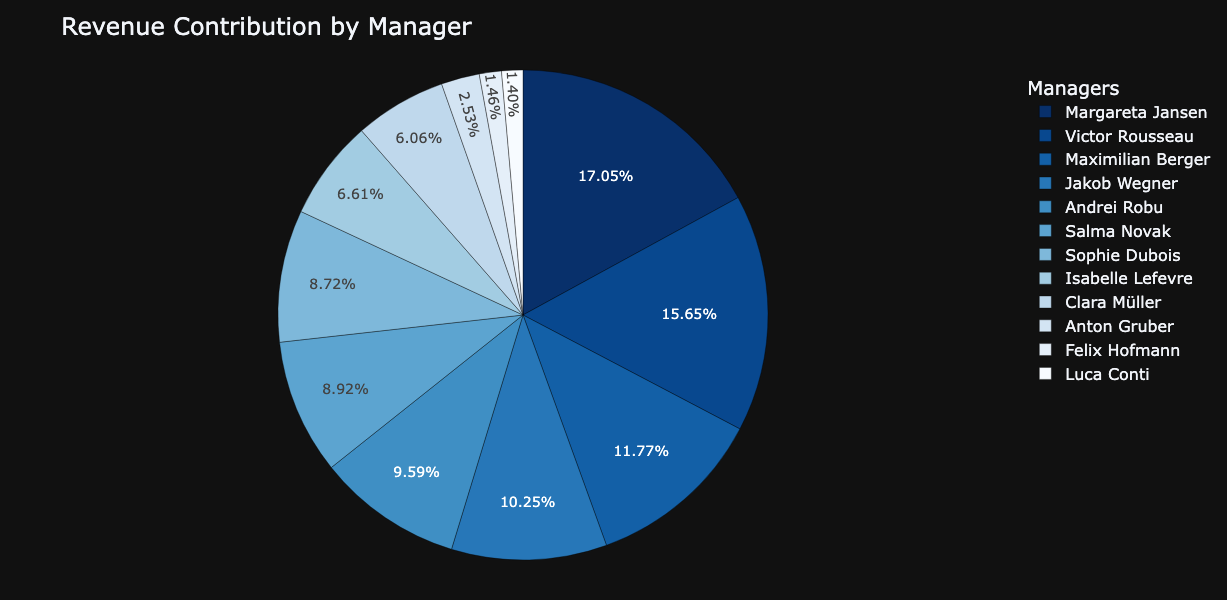

In [161]:
# Sort managers by revenue share (descending)
df_sorted_managers = total_revenue_by_manager.sort_values("percentage", ascending=False).reset_index(drop=True)

# Stretch and reverse colour palette so that:
# → Top-performing manager gets the darkest blue
colors = px.colors.sample_colorscale("Blues", [i / (len(df_sorted_managers)-1) for i in range(len(df_sorted_managers))])
colors = colors[::-1]

# Create a clean, dark-themed pie chart to visualise each manager’s contribution to total revenue
fig = px.pie(
    df_sorted_managers,
    values="percentage",
    names="manager",
    title="Revenue Contribution by Manager"
)

# Customise trace formatting: clockwise slices, percentage labels inside, black outlines for contrast
fig.update_traces(
    direction="clockwise",
    textposition="inside",
    texttemplate="%{value:.2f}%",
    marker=dict(colors=colors, line=dict(color="rgba(0,0,0,0.35)", width=1)),
    textfont=dict(size=14)
)

# Layout: dark theme, centralised legend, bold title, spacing for readability
fig.update_layout(
    template="plotly_dark",
    width=1000, height=600,
    title=dict(font=dict(size=24)),
    legend=dict(title="Managers", font=dict(size=16), bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=40, r=40, t=70, b=40)
)

# Render final chart
fig.show()

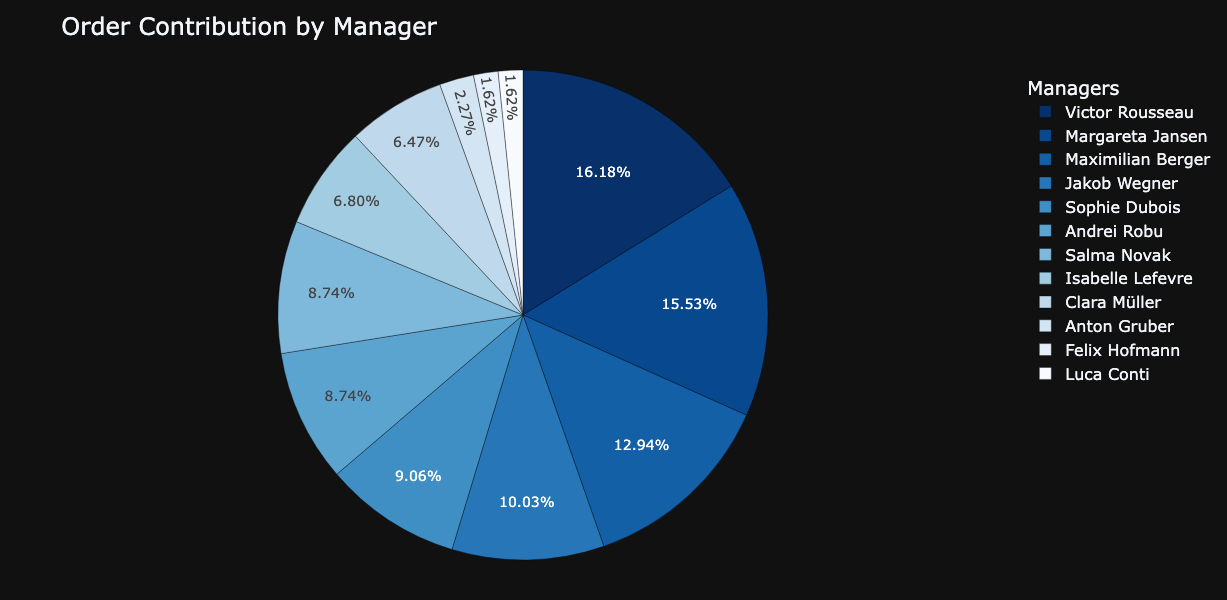

In [162]:
# Sort managers by order share (descending)
df_sorted_orders = total_numbers_of_orders_by_manager.sort_values("percentage", ascending=False).reset_index(drop=True)

# Stretch and reverse colour palette so that:
# → Top-performing manager gets the darkest blue (same as revenue chart)
colors_orders = px.colors.sample_colorscale("Blues", [i / (len(df_sorted_orders)-1) for i in range(len(df_sorted_orders))])
colors_orders = colors_orders[::-1]

# Create a dark-themed pie chart to visualise order distribution
fig = px.pie(
    df_sorted_orders,
    values="percentage",
    names="manager",
    title="Order Contribution by Manager"
)

# Format the slices: clockwise, inner text, outlines
fig.update_traces(
    direction="clockwise",
    textposition="inside",
    texttemplate="%{value:.2f}%",
    marker=dict(colors=colors_orders, line=dict(color="rgba(0,0,0,0.35)", width=1)),
    textfont=dict(size=14)
)

# Apply consistent layout styling
fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=600,
    title=dict(font=dict(size=24)),
    legend=dict(
        title="Managers",
        font=dict(size=16),
        bgcolor="rgba(0,0,0,0)"
    ),
    margin=dict(l=40, r=40, t=70, b=40)
)

# Show the chart
fig.show()

**Pie charts demonstrate the following conclusions:**

- The best manager in terms of revenue percentage is **Margareta Jansen**, contributing over 17% of the company’s revenue.
- The best manager in terms of order percentage is **Victor Rousseau**, fulfilling more than 16% of the orders.
- The worst performance belongs to **Luca Conti**.
- This month, there is no clear top five leaders in revenue and order percentages who stand out significantly from the rest.

---

## Summary

The project focused on analyzing key business metrics, identifying successful managers and brands, and optimizing the assortment and sales processes.

- **Sales Dynamics**: Monthly revenue, average receipt, and order count were analyzed to identify trends and anomalies. This helped pinpoint peak activity days and possible CRM issues.
- **Brand Popularity**: Customer interest in brands was studied, revealing top-performing brands and those with a high number of unsold products. Brands occupying virtual "shelf space" without demand were identified.
- **Manager Performance**: Graphs and metrics were built to evaluate each manager's contribution to total revenue and order count. Recommendations were made for rewarding top performers and motivating others.
- **Order Analysis**: Reasons for repeated orders on specific days were investigated, leading to the hypothesis of potential CRM malfunctions.
- **Key Metrics**: Monthly metrics, including revenue, average receipt, and order count, were calculated and visualized to support strategic decisions.

**Practical Implications**:
The project results can be used to:
1. Optimize the product assortment by removing brands with low demand.
2. Make informed decisions about employee rewards.
3. Improve CRM systems to prevent repeated and canceled orders.
4. Plan marketing and operational activities to increase revenue.

The project concluded with a strong focus on data visualization, making the insights clear and actionable for the business.